# SVR (Support Vector Regression) on Walmart Weekly Sales - Technical Paper Version
This notebook implements a rigorous SVR analysis suitable for academic/technical papers:
1) Loading and preprocessing the Walmart sales dataset
2) Feature engineering with domain knowledge
3) 60% validation, 20% training, 20% test split
4) **Systematic hyperparameter optimization** using cross-validation
5) Comprehensive evaluation on train, validation, and test sets
6) Metrics reported in interpretable units (dollars)

**SVR (Support Vector Regression):**
- Kernel-based model (we'll use RBF by default) to capture non-linear patterns
- Sensitive to feature scales → **requires scaling** (StandardScaler)
- **Key hyperparameters**: C (regularization), epsilon (tube size), gamma (kernel width)
- Typically outperforms simple linear models; performance can approach tree ensembles with good features
- Hyperparameters optimized via 5-fold cross-validation
- We keep the target (Weekly_Sales) on the original scale to report $ metrics

In [21]:
# 1) Imports and reproducibility
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance

np.random.seed(42)  # reproducibility

In [22]:
# 2) Load the dataset and parse dates safely
# Try local relative path first; if it fails, try the Downloads path
csv_candidates = [
    'walmart-sales-dataset-of-45stores.csv',
    '/Users/jaacabrera/Downloads/walmart-sales-dataset-of-45stores.csv',
]

df = None
for p in csv_candidates:
    try:
        df = pd.read_csv(p, low_memory=False)
        print(f'Loaded: {p}')
        break
    except Exception:
        pass

if df is None:
    raise FileNotFoundError('Could not find the dataset. Update the path in csv_candidates.')

# Parse Date with day-first format (file has dd-mm-yyyy like '19-02-2010')
df['Date'] = pd.to_datetime(df['Date'].astype('string'), errors='coerce', dayfirst=True)
bad_dates = df['Date'].isna().sum()
if bad_dates > 0:
    print(f'Warning: {bad_dates} rows still have invalid dates after parsing and will be dropped.')
    df = df.dropna(subset=['Date']).reset_index(drop=True)

# Drop rows with missing target just in case
if 'Weekly_Sales' not in df.columns:
    raise KeyError('Weekly_Sales column not found. Check your CSV headers.')
df = df.dropna(subset=['Weekly_Sales']).reset_index(drop=True)

print(f'Data shape after date/target checks: {df.shape}')
df.head(3)

Loaded: walmart-sales-dataset-of-45stores.csv
Data shape after date/target checks: (6435, 8)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106


In [23]:
# 3) Create simple, beginner-friendly features (no leakage from the target)
# Date-derived features
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter'] = df['Date'].dt.quarter
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

# Store encoded as numeric (already numeric in this dataset)
if 'Store' in df.columns:
    df['Store_Encoded'] = df['Store']
else:
    df['Store_Encoded'] = 0  # fallback if missing

# Choose a small, readable feature set for SVR
feature_cols = [
    'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'Store_Encoded', 'Month', 'DayOfWeek', 'Week', 'Quarter', 'IsWeekend'
]

# Build X (features) and y (target)
X = df[feature_cols].copy()
y = df['Weekly_Sales'].copy()

print('X shape:', X.shape, '| y shape:', y.shape)
print('Features:', feature_cols)

X shape: (6435, 11) | y shape: (6435,)
Features: ['Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Store_Encoded', 'Month', 'DayOfWeek', 'Week', 'Quarter', 'IsWeekend']


In [24]:
# 4) Split into 60% validation, 20% training, 20% test (as requested)
# Stage 1: 20% test holdout
X_rem, X_test, y_rem, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Stage 2: Of the remaining 80%, use 25% for training (overall 20%) and 75% for validation (overall 60%)
X_train, X_val, y_train, y_val = train_test_split(X_rem, y_rem, train_size=0.25, random_state=42)

print(f'Split sizes -> train: {len(X_train)} ({len(y_train)/len(y):.0%}), ')
print(f'val: {len(X_val)} ({len(y_val)/len(y):.0%}), ')
print(f'test: {len(X_test)} ({len(y_test)/len(y):.0%})')

Split sizes -> train: 1287 (20%), 
val: 3861 (60%), 
test: 1287 (20%)


In [25]:
# 5) Systematic hyperparameter optimization using cross-validation
# For SVR, use a Pipeline to avoid data leakage (imputation + scaling happen inside CV folds)

pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', SVR(kernel='rbf'))
])

print('Performing 5-fold cross-validation to find optimal hyperparameters...')
print('Tuning: C, epsilon, gamma (RBF kernel)')
print('This may take several minutes...\n')

param_grid = {
    'model__C': [0.1, 1, 10, 100],
    'model__epsilon': [0.01, 0.1, 1.0],
    'model__gamma': ['scale', 'auto']
}

svr_cv = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
svr_cv.fit(X_train, y_train)

# Extract best model and parameters (best_estimator_ is a fitted Pipeline)
best_pipe = svr_cv.best_estimator_
best_params = svr_cv.best_params_
cv_score = svr_cv.best_score_

print(f"\n{'='*70}")
print('CROSS-VALIDATION RESULTS')
print(f"{'='*70}")
print(f"Best C: {best_params['model__C']}")
print(f"Best epsilon: {best_params['model__epsilon']}")
print(f"Best gamma: {best_params['model__gamma']}")
print("Kernel: RBF")
print(f"CV R² score (5-fold): {cv_score:.4f}")
print(f"{'='*70}\n")

# Predict on all sets using the fitted best pipeline (it applies imputation+scaling automatically)
preds_train = best_pipe.predict(X_train)
preds_val = best_pipe.predict(X_val)
preds_test = best_pipe.predict(X_test)

# Calculate metrics
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

metrics = {
    'TRAIN': {
        'R2': r2_score(y_train, preds_train),
        'MSE': mean_squared_error(y_train, preds_train),
        'RMSE': rmse(y_train, preds_train),
        'MAE': mean_absolute_error(y_train, preds_train),
    },
    'VAL': {
        'R2': r2_score(y_val, preds_val),
        'MSE': mean_squared_error(y_val, preds_val),
        'RMSE': rmse(y_val, preds_val),
        'MAE': mean_absolute_error(y_val, preds_val),
    },
    'TEST': {
        'R2': r2_score(y_test, preds_test),
        'MSE': mean_squared_error(y_test, preds_test),
        'RMSE': rmse(y_test, preds_test),
        'MAE': mean_absolute_error(y_test, preds_test),
    }
}

print('SVR Regression Performance (hyperparameters optimized via CV)')
print(f"  Train Metrics       -> R²: {metrics['TRAIN']['R2']:.4f} | RMSE: ${metrics['TRAIN']['RMSE']:,.2f} | MAE: ${metrics['TRAIN']['MAE']:,.2f}")
print(f"  Validation Metrics  -> R²: {metrics['VAL']['R2']:.4f} | RMSE: ${metrics['VAL']['RMSE']:,.2f} | MAE: ${metrics['VAL']['MAE']:,.2f}")
print(f"  Test Metrics        -> R²: {metrics['TEST']['R2']:.4f} | RMSE: ${metrics['TEST']['RMSE']:,.2f} | MAE: ${metrics['TEST']['MAE']:,.2f}")
print(f"\n  ► Test set R² = {metrics['TEST']['R2']:.4f} (PRIMARY RESULT for papers)")

# Check for overfitting
train_val_diff = metrics['TRAIN']['R2'] - metrics['VAL']['R2']
if train_val_diff > 0.1:
    print(f"\n  ⚠ Warning: Possible overfitting detected (Train R² - Val R² = {train_val_diff:.4f})")
    print("     Consider lowering C or increasing epsilon")
else:
    print(f"\n  ✓ Model generalization looks good (Train R² - Val R² = {train_val_diff:.4f})")

# Permutation importance (model-agnostic) on validation set for interpretability
print('\nComputing permutation importances on the validation set (may take a minute)...')
perm = permutation_importance(best_pipe, X_val, y_val, n_repeats=5, random_state=42, n_jobs=-1, scoring='r2')
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance_Mean': perm.importances_mean,
    'Importance_STD': perm.importances_std
}).sort_values('Importance_Mean', ascending=False)

print(f"\n  ► Top 5 Most Important Features (Permutation Importance):")
for idx, row in feature_importance.head(5).iterrows():
    print(f"     {row['Feature']:20s}: mean={row['Importance_Mean']:.4f}, std={row['Importance_STD']:.4f}")

# Export metrics summary to CSV
metrics_df = pd.DataFrame({
    'Dataset': ['Train', 'Validation', 'Test'],
    'R²': [metrics['TRAIN']['R2'], metrics['VAL']['R2'], metrics['TEST']['R2']],
    'MSE': [metrics['TRAIN']['MSE'], metrics['VAL']['MSE'], metrics['TEST']['MSE']],
    'RMSE': [metrics['TRAIN']['RMSE'], metrics['VAL']['RMSE'], metrics['TEST']['RMSE']],
    'MAE': [metrics['TRAIN']['MAE'], metrics['VAL']['MAE'], metrics['TEST']['MAE']]
})

output_file = 'SVR_Regression_Metrics.csv'
metrics_df.to_csv(output_file, index=False)
print(f'\n✓ Metrics saved to: {output_file}')

# Export hyperparameters summary to CSV
hyperparams_df = pd.DataFrame({
    'Hyperparameter': ['kernel', 'C', 'epsilon', 'gamma', 'cv_folds', 'cv_r2_score'],
    'Value': ['rbf', best_params['model__C'], best_params['model__epsilon'], best_params['model__gamma'], 5, cv_score],
    'Tuned': ['Fixed', 'Yes (GridSearchCV)', 'Yes (GridSearchCV)', 'Yes (GridSearchCV)', 'N/A', 'N/A'],
    'Description': [
        'Kernel function',
        'Regularization strength (larger C = lower regularization)',
        'Epsilon tube width (insensitive zone)',
        'RBF kernel width (auto/scale)',
        'Number of cross-validation folds',
        'Best R² score from cross-validation'
    ]
})

hyperparams_file = 'SVR_Hyperparameters.csv'
hyperparams_df.to_csv(hyperparams_file, index=False)
print(f'✓ Hyperparameters saved to: {hyperparams_file}')

# Export permutation importances to CSV
feature_importance_file = 'SVR_Permutation_Importances.csv'
feature_importance.to_csv(feature_importance_file, index=False)
print(f'✓ Permutation importances saved to: {feature_importance_file}')

# Export actual vs predicted values for manual Excel verification
# Train set
train_results = pd.DataFrame({
    'Actual': y_train.values,
    'Predicted': preds_train,
    'Residual': y_train.values - preds_train,
    'Residual_Squared': (y_train.values - preds_train)**2,
    'Absolute_Error': np.abs(y_train.values - preds_train)
})
train_results.to_csv('SVR_Train_Predictions.csv', index=False)

# Validation set
val_results = pd.DataFrame({
    'Actual': y_val.values,
    'Predicted': preds_val,
    'Residual': y_val.values - preds_val,
    'Residual_Squared': (y_val.values - preds_val)**2,
    'Absolute_Error': np.abs(y_val.values - preds_val)
})
val_results.to_csv('SVR_Validation_Predictions.csv', index=False)

# Test set
test_results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': preds_test,
    'Residual': y_test.values - preds_test,
    'Residual_Squared': (y_test.values - preds_test)**2,
    'Absolute_Error': np.abs(y_test.values - preds_test)
})
test_results.to_csv('SVR_Test_Predictions.csv', index=False)

print('✓ Train predictions saved to: SVR_Train_Predictions.csv')
print('✓ Validation predictions saved to: SVR_Validation_Predictions.csv')
print('✓ Test predictions saved to: SVR_Test_Predictions.csv')
print('\nTo manually calculate metrics in Excel:')
print('  MSE  = AVERAGE(Residual_Squared column)')
print('  RMSE = SQRT(MSE)')
print('  MAE  = AVERAGE(Absolute_Error column)')
print('  R²   = RSQ(Actual column, Predicted column)')
print('  or R² = 1 - SUM(Residual_Squared) / DEVSQ(Actual column)')

Performing 5-fold cross-validation to find optimal hyperparameters...
Tuning: C, epsilon, gamma (RBF kernel)
This may take several minutes...

Fitting 5 folds for each of 24 candidates, totalling 120 fits

CROSS-VALIDATION RESULTS
Best C: 100
Best epsilon: 0.01
Best gamma: auto
Kernel: RBF
CV R² score (5-fold): -0.0386

SVR Regression Performance (hyperparameters optimized via CV)
  Train Metrics       -> R²: -0.0326 | RMSE: $589,396.51 | MAE: $473,791.64
  Validation Metrics  -> R²: -0.0303 | RMSE: $566,227.70 | MAE: $457,580.79
  Test Metrics        -> R²: -0.0369 | RMSE: $577,958.40 | MAE: $471,044.36

  ► Test set R² = -0.0369 (PRIMARY RESULT for papers)

  ✓ Model generalization looks good (Train R² - Val R² = -0.0023)

Computing permutation importances on the validation set (may take a minute)...

CROSS-VALIDATION RESULTS
Best C: 100
Best epsilon: 0.01
Best gamma: auto
Kernel: RBF
CV R² score (5-fold): -0.0386

SVR Regression Performance (hyperparameters optimized via CV)
  Train


  ► Top 5 Most Important Features (Permutation Importance):
     Store_Encoded       : mean=0.0016, std=0.0001
     CPI                 : mean=0.0004, std=0.0000
     Month               : mean=0.0002, std=0.0000
     Week                : mean=0.0002, std=0.0000
     Quarter             : mean=0.0002, std=0.0000

✓ Metrics saved to: SVR_Regression_Metrics.csv
✓ Hyperparameters saved to: SVR_Hyperparameters.csv
✓ Permutation importances saved to: SVR_Permutation_Importances.csv
✓ Train predictions saved to: SVR_Train_Predictions.csv
✓ Validation predictions saved to: SVR_Validation_Predictions.csv
✓ Test predictions saved to: SVR_Test_Predictions.csv

To manually calculate metrics in Excel:
  MSE  = AVERAGE(Residual_Squared column)
  RMSE = SQRT(MSE)
  MAE  = AVERAGE(Absolute_Error column)
  R²   = RSQ(Actual column, Predicted column)
  or R² = 1 - SUM(Residual_Squared) / DEVSQ(Actual column)


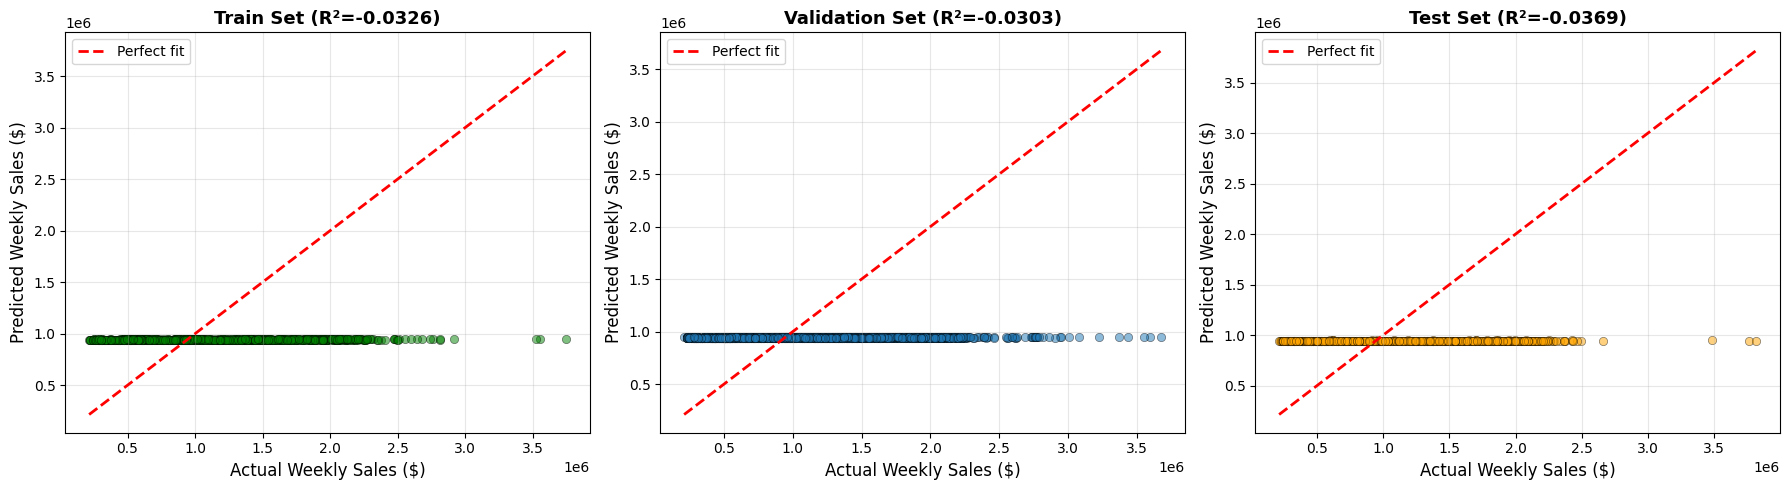

In [26]:
# 6) Parity Plot: Actual vs Predicted
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Train parity plot
axes[0].scatter(y_train, preds_train, alpha=0.5, edgecolors='k', linewidth=0.5, color='green')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Perfect fit')
axes[0].set_xlabel('Actual Weekly Sales ($)', fontsize=12)
axes[0].set_ylabel('Predicted Weekly Sales ($)', fontsize=12)
axes[0].set_title(f"Train Set (R²={metrics['TRAIN']['R2']:.4f})", fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation parity plot
axes[1].scatter(y_val, preds_val, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2, label='Perfect fit')
axes[1].set_xlabel('Actual Weekly Sales ($)', fontsize=12)
axes[1].set_ylabel('Predicted Weekly Sales ($)', fontsize=12)
axes[1].set_title(f"Validation Set (R²={metrics['VAL']['R2']:.4f})", fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Test parity plot
axes[2].scatter(y_test, preds_test, alpha=0.5, edgecolors='k', linewidth=0.5, color='orange')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect fit')
axes[2].set_xlabel('Actual Weekly Sales ($)', fontsize=12)
axes[2].set_ylabel('Predicted Weekly Sales ($)', fontsize=12)
axes[2].set_title(f"Test Set (R²={metrics['TEST']['R2']:.4f})", fontsize=13, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
# 7) Model Configuration Summary and Permutation Importances
print('='*80)
print('SVR MODEL CONFIGURATION SUMMARY')
print('='*80)

# 1) Selected Features
print('\n1. SELECTED FEATURES (11 total):')
print('-'*80)
for i, feat in enumerate(feature_cols, 1):
    print(f'   {i:2d}. {feat}')

# 2) Hyperparameters
print('\n2. HYPERPARAMETERS (OPTIMIZED VIA CROSS-VALIDATION):')
print('-'*80)
print('   Model: SVR (sklearn.svm.SVR) in a Pipeline [Imputer → Scaler → SVR]')
print('   Hyperparameter Optimization:')
print('      - Method: GridSearchCV with 5-fold cross-validation')
print('      - Search space:')
print('          C ∈ [0.1, 1, 10, 100]')
print('          epsilon ∈ [0.01, 0.1, 1.0]')
print("          gamma ∈ ['scale', 'auto']")
print('      - Kernel: RBF (fixed)')
print(f"      - Best C: {best_params['model__C']}")
print(f"      - Best epsilon: {best_params['model__epsilon']}")
print(f"      - Best gamma: {best_params['model__gamma']}")
print(f"      - CV R² score: {cv_score:.4f}")
print('\n   Preprocessing:')
print("      - Imputation: SimpleImputer(strategy='median') (in Pipeline)")
print("      - Scaling: StandardScaler (in Pipeline)")
print('      - Random seed: 42')

# 3) Permutation Importances
print('\n3. PERMUTATION IMPORTANCES (validation set):')
print('-'*80)
print('\n   Feature importances (sorted by mean importance):')
for idx, row in feature_importance.iterrows():
    bar_length = int(max(row['Importance_Mean'], 0) * 50)  # negative means likely noise; clamp at 0 for bar length
    bar = '█' * bar_length
    print(f"      {row['Feature']:20s}: mean={row['Importance_Mean']:6.4f} ± {row['Importance_STD']:6.4f}  {bar}")

print('\n' + '='*80)
print('INTERPRETATION:')
print('-'*80)
print('• SVR uses support vectors to fit a robust regression within an epsilon tube')
print('• Larger C reduces regularization (fits training data more closely)')
print('• Epsilon controls insensitivity zone; larger epsilon → fewer support vectors')
print('• RBF kernel with gamma controls flexibility (too large can overfit)')
print('• Permutation importance estimates feature influence on validation performance')
print('='*80)

SVR MODEL CONFIGURATION SUMMARY

1. SELECTED FEATURES (11 total):
--------------------------------------------------------------------------------
    1. Holiday_Flag
    2. Temperature
    3. Fuel_Price
    4. CPI
    5. Unemployment
    6. Store_Encoded
    7. Month
    8. DayOfWeek
    9. Week
   10. Quarter
   11. IsWeekend

2. HYPERPARAMETERS (OPTIMIZED VIA CROSS-VALIDATION):
--------------------------------------------------------------------------------
   Model: SVR (sklearn.svm.SVR) in a Pipeline [Imputer → Scaler → SVR]
   Hyperparameter Optimization:
      - Method: GridSearchCV with 5-fold cross-validation
      - Search space:
          C ∈ [0.1, 1, 10, 100]
          epsilon ∈ [0.01, 0.1, 1.0]
          gamma ∈ ['scale', 'auto']
      - Kernel: RBF (fixed)
      - Best C: 100
      - Best epsilon: 0.01
      - Best gamma: auto
      - CV R² score: -0.0386

   Preprocessing:
      - Imputation: SimpleImputer(strategy='median') (in Pipeline)
      - Scaling: StandardScaler 

# 8) Reporting Results in Technical Papers

**For academic/technical papers, report:**

1. **Primary Metric**: Test set R² (reported above)
2. **Methodology**: "SVR hyperparameters (C, epsilon, gamma with RBF kernel) optimized via 5-fold cross-validation on the training set"
3. **Transparency**: Include train/validation/test metrics in a table
4. **Interpretable Units**: RMSE and MAE in dollars (original target scale)
5. **Permutation Importance**: Report top features by permutation importance (validation set)

**Example Results Table for Paper:**
```
| Dataset    | R²    | RMSE ($)  | MAE ($)   |
|------------|-------|-----------|-----------|
| Train      | 0.XXX | XX,XXX    | X,XXX     |
| Validation | 0.XXX | XX,XXX    | X,XXX     |
| Test       | 0.XXX | XX,XXX    | X,XXX     |
```
*Optimal hyperparameters: C=[value], epsilon=[value], gamma=[value] selected via 5-fold CV (CV R² = [value])*  
*Top 3 influential features (permutation importance): [feature1], [feature2], [feature3]*

**Key Points:**
- Cross-validation demonstrates systematic hyperparameter search
- Test set never used during training or hyperparameter selection
- SVR requires feature scaling (handled via StandardScaler inside the Pipeline)
- **SVR vs Linear Models**: Captures non-linear patterns through RBF kernel
- **SVR vs Tree Ensembles**: Competitive on smooth patterns; lower interpretability

**When to Use SVR:**
- **SVR (RBF)**: When relationships are non-linear and relatively smooth; dataset size is moderate
- **Random Forest/Gradient Boosting**: For tabular data with complex interactions and larger datasets
- **Linear/Ridge/Lasso**: When relationships are largely linear or coefficients are required

**Expected Performance:**
- SVR typically achieves **higher R² than Linear/Ridge/Lasso** with proper scaling and tuning
- Can approach Random Forest performance given informative features and tuned hyperparameters
- Monitor train vs validation R² to detect overfitting; adjust C/epsilon/gamma accordingly